state+goal->action's learning

In [2]:
import torch


def generate_state_goal(batch_size=1024):
    """
    :param batch_size:
    :return: obs,expert_action,here obs stands for all inputs that the model is trained on, thus we concat the goal with state.
    """
    state=torch.rand(batch_size, 2)*2-1
    goal=torch.rand(batch_size, 2)*2-1
    obs=torch.cat([state,goal],dim=1)
    expert_action=goal-state
    return obs,expert_action


In [3]:
import torch.nn as nn
import torch.nn.functional as F
class ObsBc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(4,1024),
            nn.ReLU(),
            nn.Linear(1024,1024),
            nn.ReLU(),
            nn.Linear(1024,2),
        )
    def forward(self,x):
        return self.net(x)

In [4]:
epoch=5000
model=ObsBc()
optim=torch.optim.Adam(model.parameters(),lr=0.001)
model.train()
loss_list=[]
for i in range(epoch):
    obs,expert_action=generate_state_goal(batch_size=1024)
    pred=model.forward(obs)
    loss=F.mse_loss(pred,expert_action)
    loss_list.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
    if i%50==0:
        print(loss.item())

0.7049342393875122
0.00018006660684477538
3.510875103529543e-05
2.1118621589266695e-05
1.5756191714899614e-05
1.3641094483318739e-05
1.0173125701840036e-05
9.38374887482496e-06
0.00011192795500392094
1.343306757917162e-05
1.1776630344684236e-05
0.00018291840387973934
1.3590116395789664e-05
1.036844423651928e-05
0.0004021989880129695
1.6126237824209966e-05
0.00010378430306445807
6.443123311328236e-06
9.285107807954773e-05
6.683771061943844e-06
5.370099643187132e-06
1.2499947843025438e-05
8.119507583614904e-06
5.647387752105715e-06
4.5084084376867395e-06
7.145878953451756e-06
3.109896351816133e-05
7.906923201517202e-06
2.1248140910756774e-05
7.3731443990254775e-06
0.0001127160940086469
8.74590750754578e-06
0.0011875651543959975
9.524344932287931e-06
6.2725548559683375e-06
7.899103366071358e-06
7.005112820479553e-06
0.00012545734352897853
4.698786142398603e-06
0.00016187512665055692
8.591879122832324e-06
1.4306118828244507e-05
4.593504854710773e-06
9.662408047006465e-06
1.433956731489161e

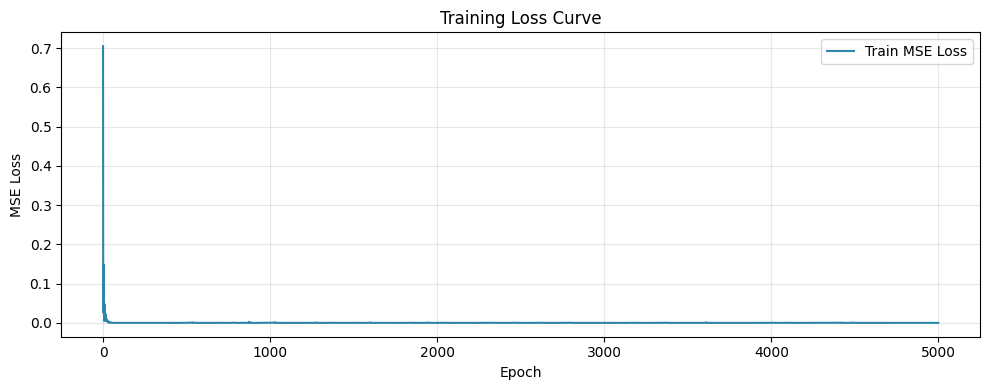

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(range(epoch), loss_list, label="Train MSE Loss", color="#2E86AB")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
state=torch.tensor([[-1.1,-1.3]])
goal=torch.tensor([[0.2,0.3]])
traj=[]
step=300
model.eval()
for i in range(step):
    with torch.no_grad():
        obs=torch.cat([state,goal],dim=1)
        pred=model(obs)
        state=state+0.1*pred
        traj.append(state)
print(f'last step is{state}')
for i in range(step):
    if i%10==0:
        print(traj[i])

last step istensor([[0.2020, 0.3015]])
tensor([[-0.9698, -1.1408]])
tensor([[-0.2070, -0.2034]])
tensor([[0.0585, 0.1249]])
tensor([[0.1516, 0.2390]])
tensor([[0.1842, 0.2794]])
tensor([[0.1958, 0.2938]])
tensor([[0.1999, 0.2988]])
tensor([[0.2013, 0.3006]])
tensor([[0.2018, 0.3012]])
tensor([[0.2019, 0.3014]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])
tensor([[0.2020, 0.3015]])


In [10]:
def rollout(model,init_state,goal,step,step_size=0.1):
    state=torch.tensor([init_state],dtype=torch.float32)
    goal=torch.tensor([goal],dtype=torch.float32)
    traj=[]
    model.eval()
    for i in range(step):
        with torch.no_grad():
            obs=torch.cat([state,goal],dim=1)
            pred=model(obs)
            state=state+0.1*pred
            traj.append(state)
    final_error=torch.norm(state-goal).item()
    print(f'final error is {final_error}')
    return traj,final_error
tests = [
    ([-1.1, -1.3], [0.2, 0.3]),
    ([0.8, -0.6], [-0.5, 0.7]),
    ([-0.9, 0.9], [0.8, -0.8]),
    ([0.1, 0.2], [-0.7, -0.4]),
    ([0.9, 0.9], [-0.9, -0.9]),
]

for init_state, goal in tests:
    traj, error = rollout(model, init_state, goal, step=100)
    print("-" * 50)

final error is 0.002469913335517049
--------------------------------------------------
final error is 0.003400776069611311
--------------------------------------------------
final error is 0.004545863717794418
--------------------------------------------------
final error is 0.003559460863471031
--------------------------------------------------
final error is 0.005496790632605553
--------------------------------------------------


final error is 0.002469913335517049


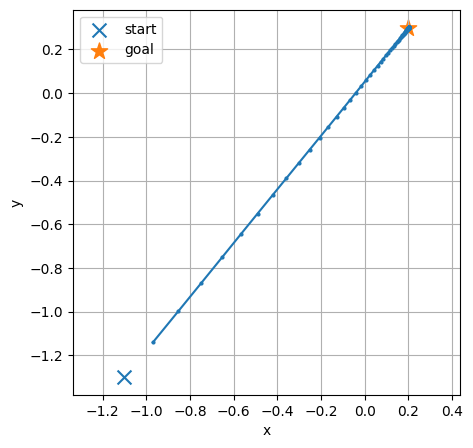

In [15]:
def plot_traj(traj, init_state, goal):
    traj_tensor = torch.cat(traj, dim=0).detach().cpu()

    xs = traj_tensor[:, 0]
    ys = traj_tensor[:, 1]

    plt.figure(figsize=(5, 5))
    plt.plot(xs, ys, marker='o', markersize=2)
    plt.scatter([init_state[0]], [init_state[1]], marker='x', s=100, label='start')
    plt.scatter([goal[0]], [goal[1]], marker='*', s=150, label='goal')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.axis("equal")
    plt.show()
init_state = [-1.1, -1.3]
goal = [0.2, 0.3]
traj, error = rollout(model, init_state, goal, step=100)
plot_traj(traj, init_state, goal)